# Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import requests, zipfile, io
# --- Etapa de BI ---#
import seaborn as sns
import matplotlib.pyplot as plt
!pip install plotly
import plotly.express as px
import os
import plotly.graph_objects as go
import plotly.subplots as sp
import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

import matplotlib.dates as mdates
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Coleta e Armazenamento

### Download nº 1:
**Nome:** Inadimplência da carteira de crédito - Total  
**Descrição:** Série histórica das taxas de inadimplência mensais no Brasil para pessoas físicas e jurídicas desde 2011.  
**Fonte:** Banco Central dos Brasil

In [2]:
url_bcb = "https://api.bcb.gov.br/dados/serie/bcdata.sgs.21082/dados?formato=csv"
df_inadimplencia = pd.read_csv(url_bcb, sep=';')

In [3]:
df_inadimplencia['valor'] = df_inadimplencia['valor'].str.replace(',', '.').astype(float)

In [4]:
df_inadimplencia['data'] = pd.to_datetime(df_inadimplencia['data'], format='%d/%m/%Y')

In [5]:
df_inadimplencia = df_inadimplencia.rename(columns={'valor': 'txa_inadimplencia'})

In [6]:
df_inadimplencia.head(3)

,data,txa_inadimplencia
0,2011-03-01,3.17
1,2011-04-01,3.24
2,2011-05-01,3.37


Exportar df_inadimplencia MENSAL:

In [7]:
# Exportação do df_inadimplencia em formato mensal
#df_inadimplencia.to_csv("df_inadimplencia_mensal.csv", index=False)

A partir desta célula o df passará a ser trimestral, para fins de análises conjuntas com outras variáveis que usam apenas essa configuração de tempo.

In [8]:
df_inadimplencia['trimestre'] = df_inadimplencia['data'].dt.to_period('Q')

In [9]:
# Média dos dados mensal para trimestral
df_inadimplencia_trimestral = (
    df_inadimplencia
    .groupby('trimestre', as_index=False)
    .agg(media_inadimplencia=('txa_inadimplencia', 'mean'))
)

df_inadimplencia_trimestral['trimestre'] = df_inadimplencia_trimestral['trimestre'].astype(str)

In [10]:
df_inadimplencia_trimestral.head(3)

,trimestre,media_inadimplencia
0,2011Q1,3.170000
1,2011Q2,3.310000
2,2011Q3,3.443333


### Download 2
**Nome:** Tabela 6691 - IPCA - Série histórica com número-índice, variação mensal e variações acumuladas a partir de 12 meses (a partir de novembro/2014)

**Parâmetros:**  
* Variável = IPCA - Variação mensal (%)  
* Mês = todas as caixas de seleção  
* Unidade Territorial = Brasil

**Fonte:** https://sidra.ibge.gov.br/Tabela/6691

In [11]:
url_ipca = "https://apisidra.ibge.gov.br/values/t/6691/n1/all/v/63/p/all/d/v63%202"
df_ipca = pd.read_json(url_ipca)

In [12]:
# Seleção das colunas de interesse
df_ipca = df_ipca[['V','D3C']]

In [13]:
# Ajuste do cabeçalho
df_ipca.columns = df_ipca.iloc[0]
df_ipca = df_ipca.drop(0).reset_index(drop=True)

In [14]:
# Converter coluna 'Valor' para float
df_ipca['Valor'] = df_ipca['Valor'].astype(float)
df_ipca = df_ipca.rename(columns={'Valor': 'txa_variacao_ipca'})
# E coluna 'Mês (Código)' para datetime
df_ipca['Mês (Código)'] = pd.to_datetime(df_ipca['Mês (Código)'], format='%Y%m')

In [15]:
df_ipca.head()

,txa_variacao_ipca,Mês (Código)
0,0.51,2014-11-01
1,0.78,2014-12-01
2,1.24,2015-01-01
3,1.22,2015-02-01
4,1.32,2015-03-01


Exportar df_ipca MENSAL:

In [16]:
# Exportação do df_ipca em formato mensal
#df_ipca.to_csv("df_ipca_mensal.csv", index=False)

A partir desta célula o df passará a ser trimestral, para fins de análises conjuntas com outras variáveis que usam apenas essa configuração de tempo.

In [17]:
# Criação da coluna trimestre
df_ipca['trimestre'] = df_ipca['Mês (Código)'].dt.to_period('Q')

# Média dos dados mensal para trimestral
df_ipca_trimestral = (
    df_ipca
    .groupby('trimestre', as_index=False)
    .agg(media_ipca=('txa_variacao_ipca', 'mean'))
)

In [18]:
df_ipca_trimestral['trimestre'] = df_ipca_trimestral['trimestre'].astype(str)

In [19]:
df_ipca_trimestral.head(3)

,trimestre,media_ipca
0,2014Q4,0.645000
1,2015Q1,1.260000
2,2015Q2,0.746667


### Download 3:  
**Nome:** Tabela 4093 - Pessoas de 14 anos ou mais de idade, total, na força de trabalho, ocupadas, desocupadas, fora da força de trabalho, em situação de informalidade e respectivas taxas e níveis, por sexo  
**Parâmetros:**  
* Variáveis: Pessoas de 14 anos ou mais de idade, na força de trabalho, na semana de referência (Mil pessoas), Pessoas de 14 anos ou mais de idade ocupadas na semana de referência (Mil pessoas) e Pessoas de 14 anos ou mais de idade, desocupadas na semana de referência (Mil pessoas).  
* Sexo = Total  
* Trimestre = todas as caixas de seleção  
* Unidade Territorial = Brasil  

**Descrição:** Quantidade de pessoas na força de trabalho, ocupadas e desocupadas.  

**Fonte:** IBGE - Pesquisa Nacional por Amostra de Domicílios Contínua trimestral (https://sidra.ibge.gov.br/tabela/4093)

In [20]:
# Download
url_forcaDeTrabalho = "https://apisidra.ibge.gov.br/values/t/4093/n1/all/v/4088,4090,4092/p/all/c2/6794"
df_ft = pd.read_json(url_forcaDeTrabalho)

In [21]:
# Seleção das colunas de interesse
df_ft = df_ft[['V', 'D2C', 'D3C']]

In [22]:
# Ajuste do cabeçalho
df_ft.columns = df_ft.iloc[0]
df_ft = df_ft.drop(0).reset_index(drop=True)

In [23]:
# Converter 'Valor' para inteiro
df_ft['Valor'] = df_ft['Valor'].astype(int)

# Substituir os códigos numéricos por descrições intuitivas
mapa_variaveis = {
    '4088': 'Forca de Trabalho',      # Força de Trabalho
    '4090': 'Ocupados',               # Ocupados
    '4092': 'Desocupados'             # Desocupados
}

df_ft['Variável (Código)'] = df_ft['Variável (Código)'].map(mapa_variaveis)

In [24]:
# Calcular percentual de desocupados

# pivotar para ter cada variável como coluna:
df_desocupados = df_ft.pivot_table(
    index='Trimestre (Código)',
    columns='Variável (Código)',
    values='Valor',
    aggfunc='sum'
).reset_index()

# criar a coluna com o cálculo de percentual de desocupados
df_desocupados['taxa_desocupados'] = (df_desocupados['Desocupados'] / df_desocupados['Forca de Trabalho']) * 100
df_desocupados['taxa_desocupados'] = df_desocupados['taxa_desocupados'].round(2)

In [25]:
# Padronização da escrita do trimestre
df_desocupados['Trimestre (Código)'] = (
    df_desocupados['Trimestre (Código)'].astype(str)
    .str[:4] + 'Q' +
    df_desocupados['Trimestre (Código)'].astype(str).str[-2:].astype(int).astype(str)
)

In [26]:
df_desocupados = df_desocupados.rename(columns={'Trimestre (Código)': 'trimestre'})

In [27]:
df_desocupados.drop(['Desocupados', 'Forca de Trabalho', 'Ocupados'], axis=1, inplace=True)

In [28]:
df_desocupados.head(3)

Variável (Código),trimestre,taxa_desocupados
0,2012Q1,7.99
1,2012Q2,7.57
2,2012Q3,7.12


In [29]:
# Exportação do df
#df_desocupados.to_csv("df_desocupados_trimestral.csv", index=False)

### Download 4:
**Nome:** Tabela 5932 - Taxa de variação do índice de volume trimestral  
**Descrição:**  
* Variável = Taxa acumulada em quatro trimestres (em relação ao mesmo período do ano anterior) (%): 1 de 1 casas decimais
* Setores e subsetores = PIB a preços de mercado
* Trimestre = Todas as caixas de seleção  
* Unidade Territorial = Brasil  

**Fonte:** https://sidra.ibge.gov.br/Tabela/5932

In [30]:
url_pib = "https://apisidra.ibge.gov.br/values/t/5932/n1/all/v/6562/p/all/c11255/90707/d/v6562%201"
df_pib = pd.read_json(url_pib)

In [31]:
# Manter apenas colunas relevantes
df_pib = df_pib[['D3C', 'V']]

In [32]:
# Ajuste do cabeçalho
df_pib.columns = df_pib.iloc[0]
df_pib = df_pib.drop(0).reset_index(drop=True)

In [33]:
# Converter coluna 'Valor' para float
df_pib['Valor'] = df_pib['Valor'].astype(float)
df_pib = df_pib.rename(columns={'Valor': 'txa_variacao_pib'})

In [34]:
# Padronização das colunas trimestrais com os dfs anteriores
df_pib['Trimestre (Código)'] = (
    df_pib['Trimestre (Código)'].astype(str)
    .str[:4] + 'Q' +
    df_pib['Trimestre (Código)'].astype(str).str[-2:].astype(int).astype(str)
)

In [35]:
df_pib.rename(columns={'Trimestre (Código)': 'trimestre'}, inplace=True)

In [36]:
df_pib.head(3)

,trimestre,txa_variacao_pib
0,1996Q1,2.5
1,1996Q2,2.1
2,1996Q3,2.3


In [37]:
# Exportação do df
#df_pib.to_csv("df_pib_trimestral.csv", index=False)

### União dos conjuntos de dados

In [38]:
cd_final_trimestral = df_pib \
    .merge(df_inadimplencia_trimestral, on='trimestre', how='inner') \
    .merge(df_desocupados, on='trimestre', how='inner') \
    .merge(df_ipca_trimestral, on='trimestre', how='inner')

In [39]:
cd_final_trimestral.head(3)

,trimestre,txa_variacao_pib,media_inadimplencia,taxa_desocupados,media_ipca
0,2014Q4,0.5,2.846667,6.56,0.645000
1,2015Q1,-0.7,2.830000,8.02,1.260000
2,2015Q2,-1.3,2.966667,8.41,0.746667


### Exportar df_final

In [40]:
cd_final_trimestral.to_excel("Conjunto Final Unificado - Trimestral.xlsx", index=False)

In [41]:
cd_final_trimestral.to_csv("Conjunto Final Unificado - Trimestral.csv", index=False)

# BI Fase 1

In [42]:
df = cd_final_trimestral.copy()
df['trimestre'] = pd.PeriodIndex(df['trimestre'], freq='Q')
df = df.set_index('trimestre')
df.index = df.index.to_timestamp()

In [43]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 45 entries, 2014-10-01 to 2025-10-01
Freq: QS-OCT
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   txa_variacao_pib     45 non-null     float64
 1   media_inadimplencia  45 non-null     float64
 2   taxa_desocupados     45 non-null     float64
 3   media_ipca           45 non-null     float64
dtypes: float64(4)
memory usage: 1.8 KB


,txa_variacao_pib,media_inadimplencia,taxa_desocupados,media_ipca
count,45.000000,45.000000,45.000000,45.000000
mean,0.906667,3.135407,10.309556,0.461148
std,2.712463,0.467692,2.822400,0.336008
min,-4.500000,2.166667,5.070000,-0.443333
25%,-1.300000,2.950000,7.940000,0.236667
50%,1.700000,3.140000,11.140000,0.413333
75%,3.000000,3.496667,12.510000,0.676667
max,4.800000,4.023333,14.910000,1.260000


In [44]:
# Verificar se o índice está na ordem correta:
df.index.is_monotonic_increasing

True

In [45]:
# valores nulos
df.isna().sum()

,0
txa_variacao_pib,0
media_inadimplencia,0
taxa_desocupados,0
media_ipca,0


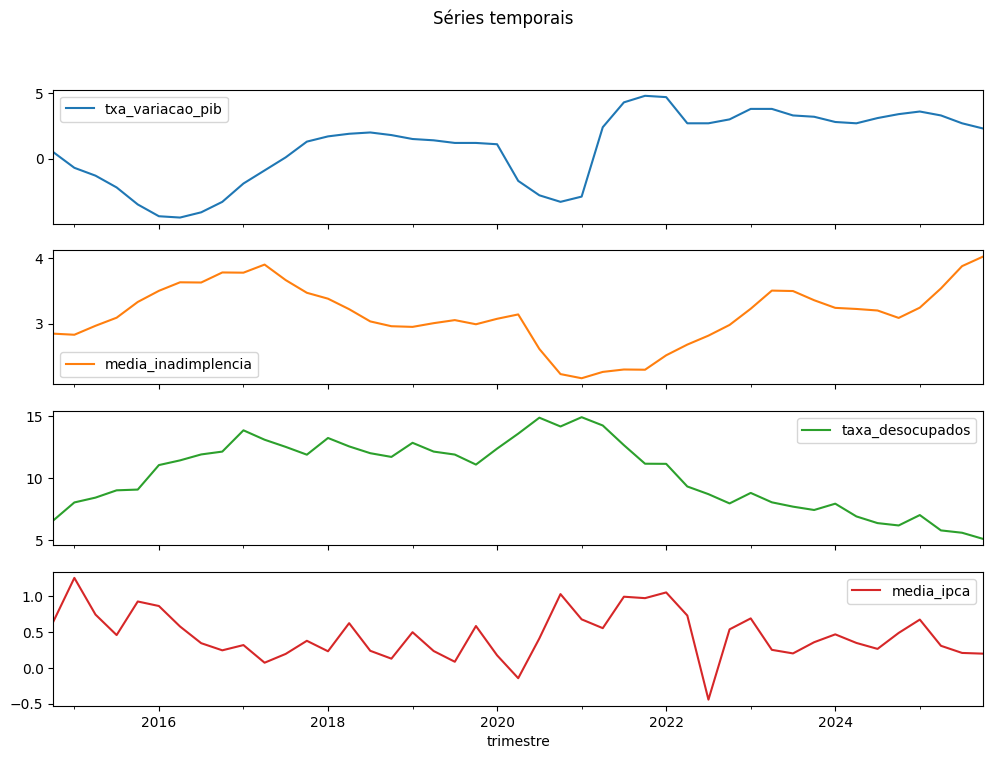

In [46]:
df.plot(subplots=True, figsize=(12,8), title="Séries temporais")
plt.show()

####Correlações simples

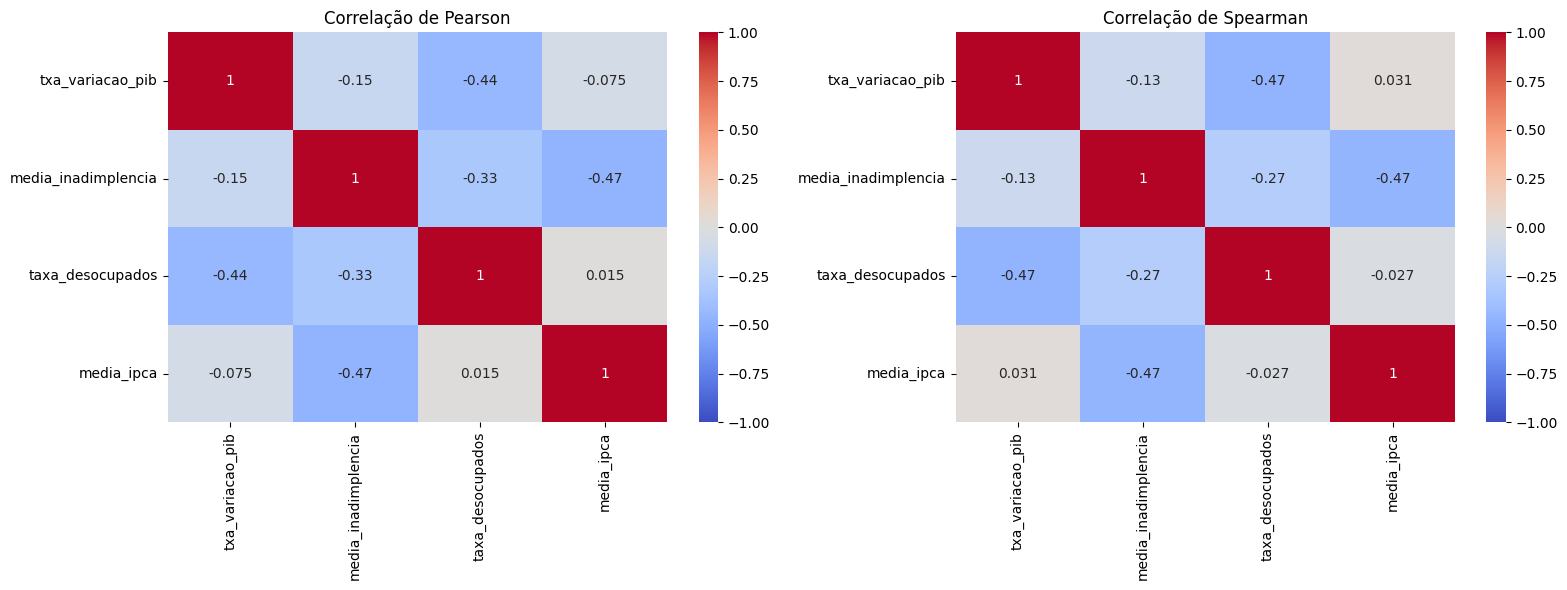

In [47]:
# Correlações
corr_pearson = df.corr(method='pearson')
corr_spearman = df.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap Pearson
sns.heatmap(corr_pearson, ax=axes[0], cmap='coolwarm', annot=True, vmin=-1, vmax=1)
axes[0].set_title('Correlação de Pearson')

# Heatmap Spearman
sns.heatmap(corr_spearman, ax=axes[1], cmap='coolwarm', annot=True, vmin=-1, vmax=1)
axes[1].set_title('Correlação de Spearman')

plt.tight_layout()
plt.show()

####Estacionariedade  
Para séries não estacionárias: diferenciar (diff) ou usar modelos que tratam tendências.

In [48]:
print('====== TESTE DE ESTACIONARIEDADE ======')
print('\np-value < 0.05 → estacionária ✔ \np-value > 0.05 → não estacionária X\n')
def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"{name}: p-value = {result[1]:.4f}")

for col in df.columns:
    adf_test(df[col], col)

====== TESTE DE ESTACIONARIEDADE ======

p-value < 0.05 → estacionária ✔ 
p-value > 0.05 → não estacionária X

txa_variacao_pib: p-value = 0.1017
media_inadimplencia: p-value = 0.2652
taxa_desocupados: p-value = 0.9451
media_ipca: p-value = 0.1140


####Decomposição:  
Para definir se é necessário usar componente sazonal no modelo.  
A série já está limpa?

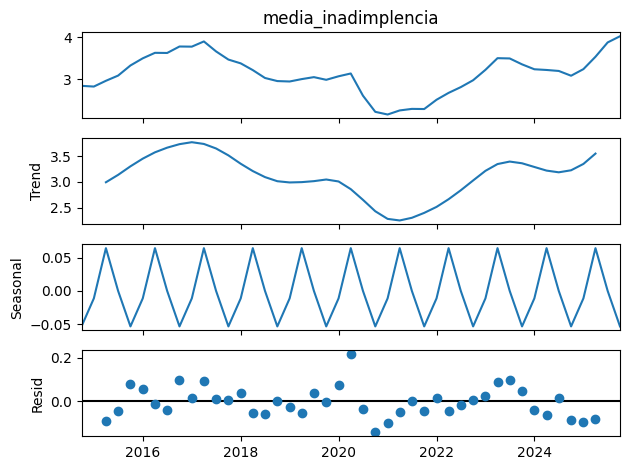

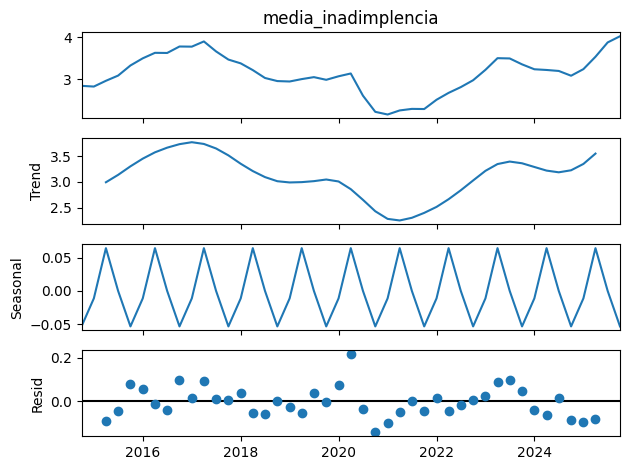

In [49]:
decomp = seasonal_decompose(df['media_inadimplencia'], model='additive', period=4)
decomp.plot()

####Conclusão primária:

1 - CORRELAÇÕES:  
Nas correlações **sem considerar defasagens** há uma relação negativa entre desemprego e inadimplencia.Em a relação linear é moderada (-0,32 | Pearson) e a relação monotônica é fraca (-0,26 | Spearman).  
Já entre inadimplencia e variação do IPCA há uma relação linear  e monotônica negativa moderada (-0,46 | Pearson e Spearman).  
  

2 - ESTACIONARIEDADE:  
Conforme o teste realizado com ADF (Augmented Dickey-Fuller) nenhuma das séries é estacionária.  

3 - DECOMPOSIÇÃO:  
No caso da **inadimplencia** a série é dominada pela tendência de longo prazo, sazonalidade anual fraca mas consistente. O período 2020–2021 foi claramente atípico, e há trajetória recente de alta na tendência.  
O desemprego tem um comportamento estrutural bem definido, com a tendência de queda robusta e sustentada. A sazonalidade é mais relevante do que na inadimplência. O choque pandêmico é bastante visível nos resíduos. A trajetória atual de queda é consistente.


---
Pontos a corrigir:   
* Tornar a série estacionária removendo tendências e sazonalidade. Para isso será feita a diferenciação.  

* Implementar defasagens: As correlações do desemprego com a taxa de inadimplência são contraintuitivas. É provável que haja defasagens nos dados, pois as consequências do aumento do desemprego podem demorar meses para aparecer na inadimplencia.


# BI Fase 2:

#### Diferenciação  
Calcula a diferença entre cada valor e o anterior. São feitas quantas diferenciações forem necessárias para tornar as séries estacionárias (média e variância constante ao longo do tempo)

In [50]:
df_diff = df.diff().dropna()

In [51]:
print('====== TESTE DE ESTACIONARIEDADE ======')
print('\np-value < 0.05 → estacionária ✔ \np-value > 0.05 → não estacionária X\n')
for col in df_diff.columns:
    adf_test(df_diff[col], col)

====== TESTE DE ESTACIONARIEDADE ======

p-value < 0.05 → estacionária ✔ 
p-value > 0.05 → não estacionária X

txa_variacao_pib: p-value = 0.0040
media_inadimplencia: p-value = 0.0097
taxa_desocupados: p-value = 0.0216
media_ipca: p-value = 0.0000


####Correlações simples - com as séries agora estacionárias

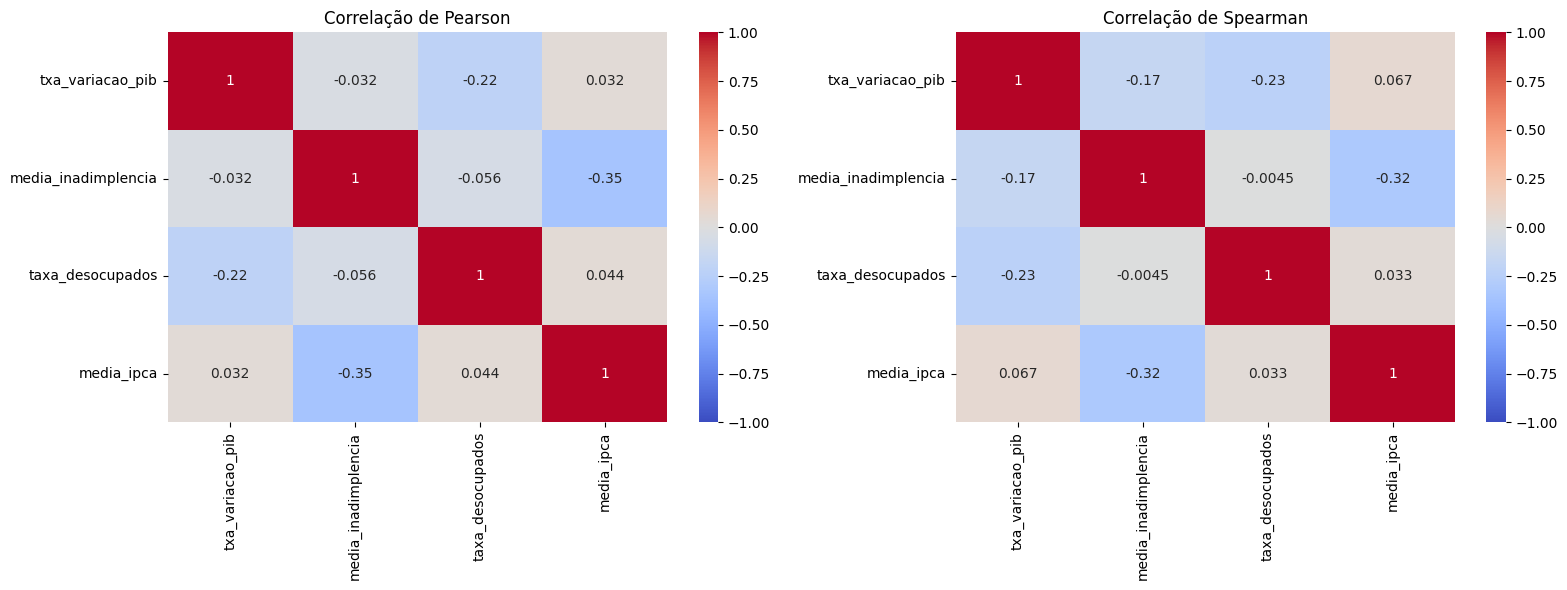

In [52]:
# Correlações
corr_pearson = df_diff.corr(method='pearson')
corr_spearman = df_diff.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap Pearson
sns.heatmap(corr_pearson, ax=axes[0], cmap='coolwarm', annot=True, vmin=-1, vmax=1)
axes[0].set_title('Correlação de Pearson')

# Heatmap Spearman
sns.heatmap(corr_spearman, ax=axes[1], cmap='coolwarm', annot=True, vmin=-1, vmax=1)
axes[1].set_title('Correlação de Spearman')

plt.tight_layout()
plt.show()

#### Correlação da inadimplencia com as demais variáveis considerando as defasagens

In [53]:
print('Correlação da Taxa de inadimplência com as defasagens da Taxa de desemprego')
for lag in range(1, 5):
    print(f"\nLag {lag}")
    print(df_diff['media_inadimplencia'].corr(df_diff['taxa_desocupados'].shift(lag)))

Correlação da Taxa de inadimplência com as defasagens da Taxa de desemprego

Lag 1
-0.0571161505889534

Lag 2
-0.3038174767676741

Lag 3
-0.17108897908265122

Lag 4
-0.06958493792896242


In [54]:
print('Correlação da Taxa de inadimplência com as defasagens da Taxa de variação do IPCA')
for lag in range(1, 5):
    print(f"\nLag {lag}")
    print(df_diff['media_inadimplencia'].corr(df_diff['media_ipca'].shift(lag)))

Correlação da Taxa de inadimplência com as defasagens da Taxa de variação do IPCA

Lag 1
-0.02573960711325096

Lag 2
0.16734720350207066

Lag 3
-0.14317468996803803

Lag 4
-0.07416874543831381


In [55]:
print('Correlação da Taxa de inadimplência com as defasagens da Taxa de variação do PIB')
for lag in range(1, 5):
    print(f"\nLag {lag}")
    print(df_diff['media_inadimplencia'].corr(df_diff['txa_variacao_pib'].shift(lag)))

Correlação da Taxa de inadimplência com as defasagens da Taxa de variação do PIB

Lag 1
0.10756583265092827

Lag 2
0.01194218724278406

Lag 3
-0.0382892370149817

Lag 4
-0.10061086466016804


####Teste de causalidade de Granger

In [56]:
grangercausalitytests(df_diff[['media_inadimplencia', 'taxa_desocupados']], maxlag=4)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0520  , p=0.8207  , df_denom=40, df_num=1
ssr based chi2 test:   chi2=0.0559  , p=0.8130  , df=1
likelihood ratio test: chi2=0.0559  , p=0.8131  , df=1
parameter F test:         F=0.0520  , p=0.8207  , df_denom=40, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=2.4816  , p=0.0974  , df_denom=37, df_num=2
ssr based chi2 test:   chi2=5.6339  , p=0.0598  , df=2
likelihood ratio test: chi2=5.2867  , p=0.0711  , df=2
parameter F test:         F=2.4816  , p=0.0974  , df_denom=37, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.7624  , p=0.1729  , df_denom=34, df_num=3
ssr based chi2 test:   chi2=6.3757  , p=0.0947  , df=3
likelihood ratio test: chi2=5.9260  , p=0.1153  , df=3
parameter F test:         F=1.7624  , p=0.1729  , df_denom=34, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=1.4272  , p=0.2483  , df_d

{np.int64(1): ({'ssr_ftest': (np.float64(0.052029193312410765),
    np.float64(0.8207312492405244),
    np.float64(40.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(0.055931382810841576),
    np.float64(0.8130461297684028),
    np.int64(1)),
   'lrtest': (np.float64(0.055895038514364614),
    np.float64(0.8131057574224858),
    np.int64(1)),
   'params_ftest': (np.float64(0.05202919331240278),
    np.float64(0.820731249240547),
    np.float64(40.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(2.4815779271930993),
    np.float64(0.09742519142699425),
    np.float64(37.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(5.633852591465415),
    np.float64(0.059789435606385936),
    np.int64(2)),
   'lrtest': (np.float64(5.2867113211649155),
    np.float64(0.07112220668827292),
    np.int64(2)),
   'params_ftest': (np.float64(2.4815779271930922),
    np.float64(0.09742519142699493),
    np.float64(37.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],


CORRELAÇÕES:  
Com as séries estacionárias a correlação entre desemprego e inadimplência caiu para -0,30 e segue negativa, mantendo o resultado contraintuitivo inicial. Nessa amostra, as variações no desemprego não estão aumentando a inadimplência, mas podem até reduzi-la.  
Pode-se sugerir algumas explicações: políticas de crédito mais restritiva em períodos de crise, auxílios governamentais como ocorreu durante a pandemia de Covid-19, ajuste comportamental,delay maior do que o que foi testado. Assim, é possível afirmar que a inadimplência não reage diretamente ao desemprego num curto prazo.  

TESTE DE GRANGER:  
O lag 2 é o mais promissor (p-valor de 0,097), mas não passa no limiar convencional de 5%, e nem mesmo no de 10% com folga. Conclusão: não há causalidade de Granger estatisticamente robusta do desemprego sobre a inadimplência nesta amostra.

# Analytics

####Modelo autorregressivo puro:  
**Por quê?**  
As variáveis externas utilizadas não estão explicando bem a dinâmica da inadimplência. É possível que a própria inadimplência contenha mais informação preditiva do que as variáveis externas.  
Se pensarmos que na prática a inadimplência se acumula ("aumento de 38% nos ultimos 10 anos" conforme SERASA) e que a recuperação é gradual, podemos tentar um modelo preditivo baseado na persistência, inércia e ciclos internos da série temporal da inadimplência.

In [57]:
model = AutoReg(df_diff['media_inadimplencia'], lags=1).fit()
print(model.summary())

                             AutoReg Model Results                             
Dep. Variable:     media_inadimplencia   No. Observations:                   44
Model:                      AutoReg(1)   Log Likelihood                  22.107
Method:                Conditional MLE   S.D. of innovations              0.145
Date:                 Thu, 09 Apr 2026   AIC                            -38.213
Time:                         19:27:25   BIC                            -32.930
Sample:                     04-01-2015   HQIC                           -36.265
                          - 10-01-2025                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0.0142      0.022      0.635      0.525      -0.030       0.058
media_inadimplencia.L1     0.5677      0.126      4.490      0.000       0.320       0.

#### Testar com a defasagem do desemprego

In [58]:
df_model = df_diff.copy()

# criar lags
df_model['inad_lag1'] = df_model['media_inadimplencia'].shift(1) #Baseado no modelo autorregressivo
df_model['taxa_desocupados_lag2'] = df_model['taxa_desocupados'].shift(2) #Baseado na correlação e teste de Granger

# remover NaNs
df_model = df_model.dropna()

In [59]:
X = df_model[['inad_lag1', 'taxa_desocupados_lag2']]
X = sm.add_constant(X)

y = df_model['media_inadimplencia']

model = sm.OLS(y, X).fit()
print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     media_inadimplencia   R-squared:                       0.401
Model:                             OLS   Adj. R-squared:                  0.370
Method:                  Least Squares   F-statistic:                     13.06
Date:                 Thu, 09 Apr 2026   Prob (F-statistic):           4.56e-05
Time:                         19:27:25   Log-Likelihood:                 23.983
No. Observations:                   42   AIC:                            -41.97
Df Residuals:                       39   BIC:                            -36.75
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const               

O modelo com a defasagem do desemprego é um pouco melhor

####Validação

In [60]:
# Separar em treino e teste:
train = df_model.iloc[:-8]
test  = df_model.iloc[-8:]

In [61]:
#Definir as variáveis
X_train = train[['inad_lag1', 'taxa_desocupados_lag2']]
X_train = sm.add_constant(X_train)

y_train = train['media_inadimplencia']

In [62]:
#Teste
X_test = test[['inad_lag1', 'taxa_desocupados_lag2']]
X_test = sm.add_constant(X_test)

y_test = test['media_inadimplencia']

In [63]:
# Ajustar o modelo
model = sm.OLS(y_train, X_train).fit()

In [64]:
# Fazer previsões
y_pred = model.predict(X_test)

In [65]:
#Calcular métricas

# MAE
mae = np.mean(np.abs(y_test - y_pred))

# RMSE
rmse = np.sqrt(np.mean((y_test - y_pred)**2))

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")


MAE:  0.1247
RMSE: 0.1470


####Validação do AR(1) que usava apenas a inadimplência

In [66]:
model_ar1 = AutoReg(train['media_inadimplencia'], lags=1).fit()

y_pred_ar1 = model_ar1.predict(
    start=test.index[0],
    end=test.index[-1]
)


y_pred_ar1 = y_pred_ar1.reindex(test.index)
y_test = test['media_inadimplencia']

# Cálcular métricas

# MAE
mae_ar1 = np.mean(np.abs(y_test - y_pred_ar1))

# RMSE
rmse_ar1 = np.sqrt(np.mean((y_test - y_pred_ar1)**2))

print(f"MAE AR(1):  {mae_ar1:.4f}")
print(f"RMSE AR(1): {rmse_ar1:.4f}")

MAE AR(1):  0.1400
RMSE AR(1): 0.1829


O modelo que usa a taxa de desemprego com defasagem continua sendo melhor.

####Modelo final e previsões

In [67]:
df_model = df_model.dropna()

X = df_model[['inad_lag1', 'taxa_desocupados_lag2']]
X = sm.add_constant(X)

y = df_model['media_inadimplencia']

model_final = sm.OLS(y, X).fit()

In [68]:
# PREVISÃO DA VARIAÇÃO DA INADIMPLÊNCIA: 1 período a frente

ultima_linha = df_model.iloc[-1]

inad_lag1 = ultima_linha['media_inadimplencia']
taxa_desocupados_lag2 = ultima_linha['taxa_desocupados_lag2']

X_new = pd.DataFrame({
    'const': [1],
    'inad_lag1': [inad_lag1],
    'taxa_desocupados_lag2': [taxa_desocupados_lag2]
})

delta_pred = model_final.predict(X_new)[0]

print(f"Previsão da variação (Δinad): {delta_pred:.4f}")

Previsão da variação (Δinad): 0.1556


In [69]:
# Previsão da próxima taxa de inadimplência (último valor + variação)
ultima_inad = df['media_inadimplencia'].iloc[-1]

inad_previsto = ultima_inad + delta_pred

print(f"Inadimplência prevista: {inad_previsto:.4f}")

Inadimplência prevista: 4.1790


OBS: Não sabemos o cenário do desemprego (será criado um cenário mais adiante, baseado nos dados já obtidos)

####Previsões para 4 períodos com intervalos de confiança em diferentes cenários de desemprego  
A função considerou o resultado contraintuitivo obtido nas explorações: Quando desemprego aumenta (cenário pessimista) a inadimplência tende a cair (e vice-versa). Por isso, no gráfico, o cenário pessimista (em que o desemprego aumenta) a taxa de inadimplência estará mais baixa.

Função de previsão

In [70]:
def prever_4_trimestres(model_final, df, df_diff, cenario_desemprego):
    previsoes = []
    intervalos_lower = []
    intervalos_upper = []

    # último nível observado da inadimplência
    ultimo_nivel = df['media_inadimplencia'].iloc[-1]

    # última variação observada da inadimplência
    inad_lag1 = df_diff['media_inadimplencia'].iloc[-1]

    # histórico das variações do desemprego
    hist_desemp = list(df_diff['taxa_desocupados'].iloc[-2:].values)

    # acrescenta cenário futuro
    hist_desemp.extend(cenario_desemprego)

    for h in range(4):
        # como o modelo usa lag 2:
        # no passo h, pega o valor correspondente de desemprego com defasagem de 2 períodos
        desemprego_lag2 = hist_desemp[h]

        X_new = pd.DataFrame({
            'const': [1],
            'inad_lag1': [inad_lag1],
            'taxa_desocupados_lag2': [desemprego_lag2]
        })

        pred = model_final.get_prediction(X_new).summary_frame()

        delta_pred = pred['mean'].iloc[0]
        lower = pred['obs_ci_lower'].iloc[0]
        upper = pred['obs_ci_upper'].iloc[0]

        # reconverter para nível
        novo_nivel = ultimo_nivel + delta_pred

        previsoes.append(novo_nivel)
        intervalos_lower.append(ultimo_nivel + lower)
        intervalos_upper.append(ultimo_nivel + upper)

        # atualizar para o próximo passo
        inad_lag1 = delta_pred
        ultimo_nivel = novo_nivel

    future_index = pd.date_range(
        start=df.index[-1],
        periods=5,
        freq='QE'
    )[1:]

    df_forecast = pd.DataFrame({
        'previsao': previsoes,
        'lower': intervalos_lower,
        'upper': intervalos_upper
    }, index=future_index)

    return df_forecast

Cenários futuros de desemprego:

In [71]:
ultimo_delta_desemp = df_diff['taxa_desocupados'].iloc[-1] #última variação trimestral do desemprego

In [72]:
# Cenário igual ao atual:
cenario_base = [ultimo_delta_desemp] * 4
# Cenário pessimista (desemprego aumenta):
cenario_pess = [
    ultimo_delta_desemp + 0.01,
    ultimo_delta_desemp + 0.01,
    ultimo_delta_desemp + 0.02,
    ultimo_delta_desemp + 0.02
]
# Cenário otimista (desemprego diminui):
cenario_otim = [
    ultimo_delta_desemp - 0.01,
    ultimo_delta_desemp - 0.01,
    ultimo_delta_desemp - 0.02,
    ultimo_delta_desemp - 0.02
]

In [73]:
# Rodar as previsões:
fc_base = prever_4_trimestres(model_final, df, df_diff, cenario_base)
fc_pess = prever_4_trimestres(model_final, df, df_diff, cenario_pess)
fc_otim = prever_4_trimestres(model_final, df, df_diff, cenario_otim)

Plotar o gráfico

In [74]:
# rótulos trimestrais para tooltip
hist_periodos = df.index.to_period('Q').astype(str)
base_periodos = fc_base.index.to_period('Q').astype(str)
otim_periodos = fc_otim.index.to_period('Q').astype(str)
pess_periodos = fc_pess.index.to_period('Q').astype(str)

# Gráfico interativo

fig = go.Figure()

# Histórico
fig.add_trace(go.Scatter(
    x=df.index,
    y=df['media_inadimplencia'].astype(float),
    mode='lines+markers',
    name='Histórico',
    customdata=np.array(hist_periodos),
    hovertemplate='Período: %{customdata}<br>Taxa: %{y:.4f}<extra></extra>'
))

# Intervalo do cenário base - limite inferior
fig.add_trace(go.Scatter(
    x=fc_base.index,
    y=fc_base['lower'].astype(float),
    mode='lines',
    name='Limite inferior (base)',
    line=dict(dash='dot'),
    customdata=np.array(base_periodos),
    hovertemplate='Período: %{customdata}<br>Limite inferior: %{y:.4f}<extra></extra>'
))

# Intervalo do cenário base - limite superior com preenchimento
fig.add_trace(go.Scatter(
    x=fc_base.index,
    y=fc_base['upper'].astype(float),
    mode='lines',
    fill='tonexty',
    name='Intervalo cenário base',
    customdata=np.array(base_periodos),
    hovertemplate='Período: %{customdata}<br>Limite superior: %{y:.4f}<extra></extra>'
))

# Cenário base
fig.add_trace(go.Scatter(
    x=fc_base.index,
    y=fc_base['previsao'].astype(float),
    mode='lines+markers',
    name='Cenário base (txa. desemprego igual)',
    line=dict(dash='dash'),
    customdata=np.array(base_periodos),
    hovertemplate='Período: %{customdata}<br>Previsão base: %{y:.4f}<extra></extra>'
))

# Cenário otimista
fig.add_trace(go.Scatter(
    x=fc_otim.index,
    y=fc_otim['previsao'].astype(float),
    mode='lines+markers',
    name='Cenário otimista (tx. desemprego cai)',
    line=dict(dash='dashdot'),
    customdata=np.array(otim_periodos),
    hovertemplate='Período: %{customdata}<br>Previsão otimista: %{y:.4f}<extra></extra>'
))

# Cenário pessimista
fig.add_trace(go.Scatter(
    x=fc_pess.index,
    y=fc_pess['previsao'].astype(float),
    mode='lines+markers',
    name='Cenário pessimista (tx. desemprego aumenta)',
    line=dict(dash='dot'),
    customdata=np.array(pess_periodos),
    hovertemplate='Período: %{customdata}<br>Previsão pessimista: %{y:.4f}<extra></extra>'
))

# linha vertical separando histórico e previsão
fig.add_vline(
    x=df.index[-1],
    line_dash='dash',
    opacity=0.6
)

fig.update_layout(
    title='Previsão de Inadimplência: Histórico + Cenários de desemprego',
    xaxis_title='Período',
    yaxis_title='Taxa de inadimplência',
    hovermode='x unified',
    template='plotly_white'
)

fig.show()

#Exportar

In [75]:
df_hist = df[['media_inadimplencia']].copy()
df_hist = df_hist.reset_index()
df_hist.columns = ['periodo', 'valor']
df_hist['tipo'] = 'histórico'
df_hist['cenario'] = 'real'


def preparar_forecast(df_forecast, nome_cenario):
    df_f = df_forecast[['previsao']].copy().reset_index()
    df_f.columns = ['periodo', 'valor']
    df_f['tipo'] = 'previsão'
    df_f['cenario'] = nome_cenario
    return df_f

df_base = preparar_forecast(fc_base, 'base')
df_otim = preparar_forecast(fc_otim, 'otimista')
df_pess = preparar_forecast(fc_pess, 'pessimista')


def preparar_intervalo(df_forecast, nome_cenario):
    df_i = df_forecast[['lower', 'upper']].copy().reset_index()
    df_i.columns = ['periodo', 'lower', 'upper']
    df_i['cenario'] = nome_cenario
    return df_i

df_intervalos = pd.concat([
    preparar_intervalo(fc_base, 'base'),
    preparar_intervalo(fc_otim, 'otimista'),
    preparar_intervalo(fc_pess, 'pessimista')
], ignore_index=True)

df_final = pd.concat([
    df_hist, df_base, df_otim, df_pess
], ignore_index=True)

In [76]:
df_final['periodo'] = pd.to_datetime(df_final['periodo'])
df_intervalos['periodo'] = pd.to_datetime(df_intervalos['periodo'])

In [77]:
df_final.to_csv('inadimplencia_dashboard.csv', index=False)
df_final.to_excel('inadimplencia_dashboard.xlsx', index=False)
df_intervalos.to_csv('intervalos_dashboard.csv', index=False)
df_intervalos.to_excel('intervalos_dashboard.xlsx', index=False)